# Lasso Regression

In [33]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
# from sklearn import linear_model or we can import lasso directly
from sklearn.linear_model import Lasso
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split

In [34]:
df = pd.read_csv(f"E:\AI and ML\Section Three\Supervised ML\insurance.csv")

In [35]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [36]:
X = df.drop(columns=["charges"])
y = df["charges"]

X = pd.get_dummies(X, columns=["region"], drop_first=True, dtype=int) # Picked region as column on which we want to do our one hot encoding
# get_dummies returning dummy variables

X["sex"] = X["sex"].map({"female": 1, "male": 0})
X["smoker"] = X["smoker"].map({"yes": 1, "no": 0})

# Train_Test_Split

In [37]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42) # 80-20 ratio

# Using Lasso Model

In [38]:
lasso_model = Lasso(alpha=0.5) # We pass alpha value in it & using Lasso model
lasso_model.fit(X_train, y_train)

# For MSE
y_pred = lasso_model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)

In [39]:
print(mse)

33601197.56637193


MSE for 0.01 is: 33597001.223820455
MSE for 0.1 is: 33597770.05720262
MSE for 0.2 is: 33598625.50374359
MSE for 0.7 is: 33602921.20016722
MSE for 3 is: 33623037.560437866
MSE for 5 is: 33639750.85985903
MSE for 6 is: 33647539.445558384
MSE for 7 is: 33655381.75956269
MSE for 9 is: 33671367.68728148
MSE for 10 is: 33679511.30099594


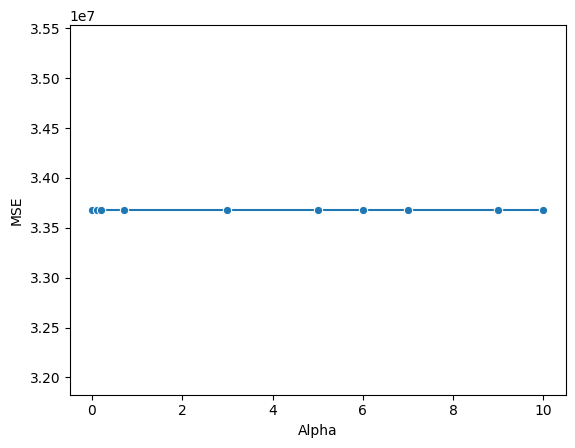

In [43]:
# Using seaborn to display in a graph
alphas = [0.01, 0.1, 0.2, 0.7, 3, 5, 6, 7, 9, 10]
mses = []

for i in alphas:
    lasso_model = Lasso(i) # We pass alpha value in it.
    lasso_model.fit(X_train, y_train)

    # For MSE
    y_pred = lasso_model.predict(X_test)
    mse = mean_squared_error(y_test, y_pred)
    print(f"MSE for {i} is:" , mse)
    mses.append(mse)

sns.lineplot(x=alphas, y=mse, marker="o")
plt.xlabel("Alpha")
plt.ylabel("MSE")
plt.show()
